In [1]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from torch.utils.data import Dataset

In [3]:
if torch.cuda.is_available:
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

In [4]:
device

'cuda'

In [5]:
#!/bin/bash
! curl -L -o animals.zip\
  https://www.kaggle.com/api/v1/datasets/download/antobenedetti/animals

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  881M  100  881M    0     0  60.4M      0  0:00:14  0:00:14 --:--:-- 83.0M


In [7]:
from zipfile import ZipFile

with ZipFile('animals.zip', 'r') as file_ref:
  file_ref.extractall()

In [8]:
from pathlib import Path

train_dir = Path('/content/animals/train')
test_dir = Path('/content/animals/val')

In [9]:
import os

In [10]:
os.listdir(train_dir)

['cat', 'lion', 'dog', 'elephant', 'horse']

In [11]:
os.listdir(test_dir)

['cat', 'lion', 'dog', 'elephant', 'horse']

In [12]:
len(os.listdir(train_dir / 'cat'))

2737

In [13]:
len(os.listdir(test_dir / 'cat'))

300

In [14]:
def show_random_image(folder_path, class_name):
  class_folder = Path(folder_path) / class_name
  random_img_name = np.random.choice(os.listdir(class_folder))
  img_path = class_folder / random_img_name
  img = Image.open(img_path)
  plt.imshow(img)
  plt.axis('off')
  return np.array(img)

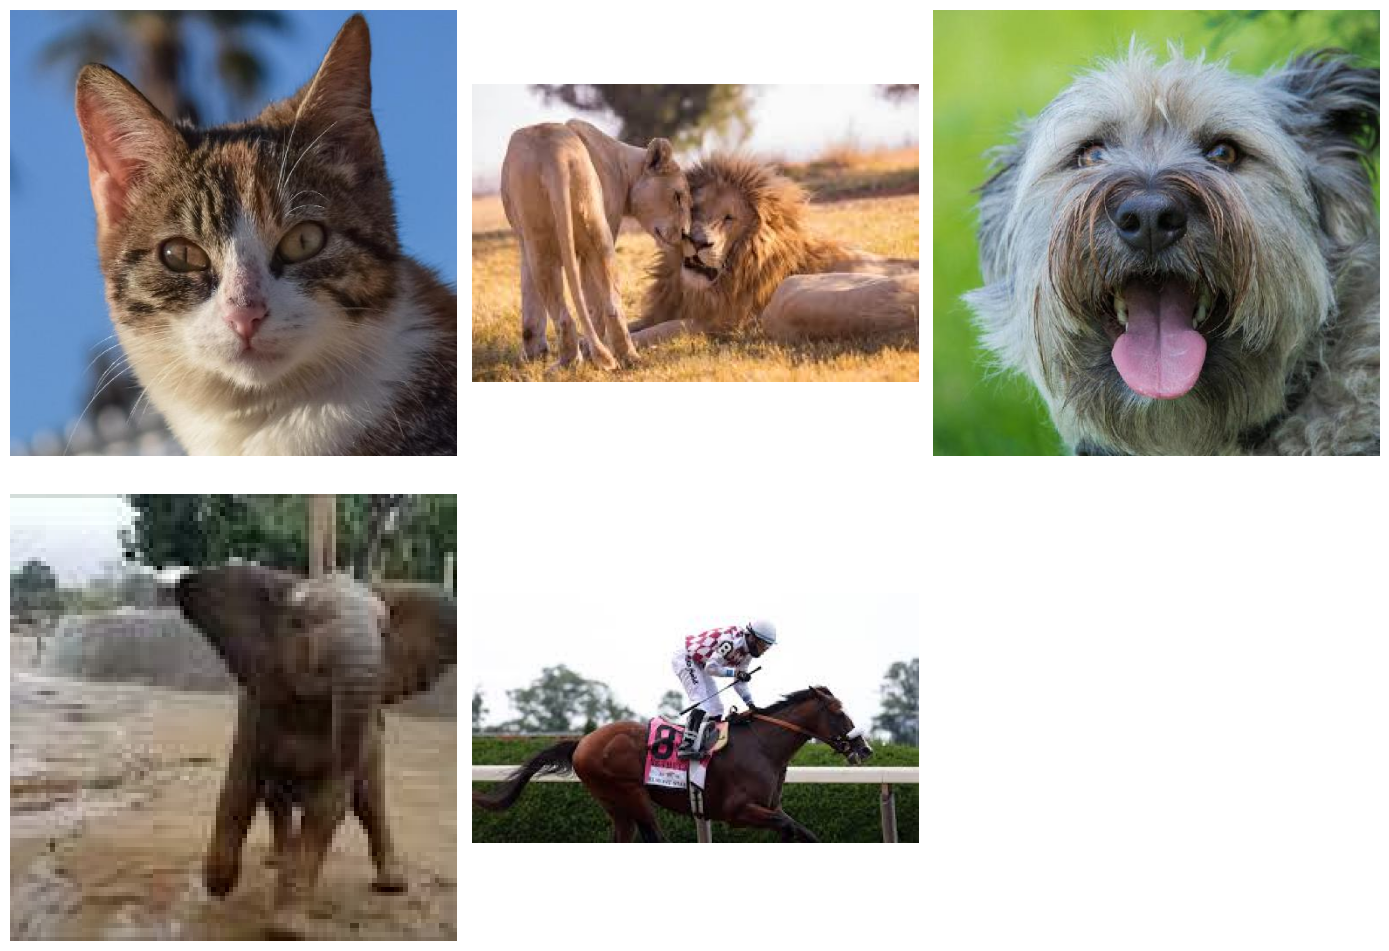

In [18]:
plt.figure(figsize=(14,10))
for i, col in enumerate(os.listdir(train_dir)):
    plt.subplot(2, 3, i+1)
    show_random_image('/content/animals/train', col)
plt.tight_layout()
plt.show()

In [19]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [22]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [23]:
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform )

In [24]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [25]:
images , labels = next(iter(train_loader))

In [26]:
images.shape

torch.Size([32, 3, 224, 224])

In [27]:
labels[:10].tolist()

[3, 3, 1, 2, 0, 1, 2, 2, 1, 3]

In [28]:
def plot_image(image_tensor):
  img = image_tensor.permute(1, 2, 0).numpy()
  img = (img -img.min()) / (img.max() - img.min())
  plt.imshow(img)
  plt.axis(False)

In [29]:
class_names =  train_dataset.classes
class_names

['cat', 'dog', 'elephant', 'horse', 'lion']

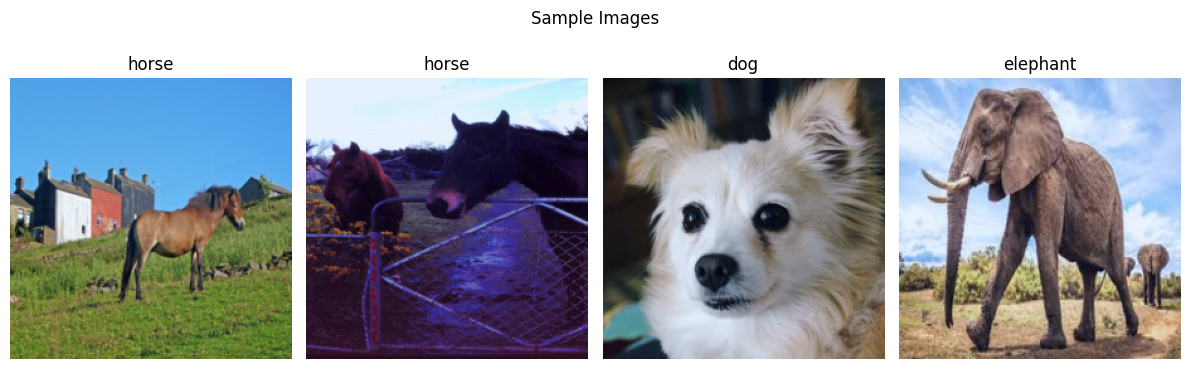

In [30]:
plt.figure(figsize=(12,4))
for i in range(4):
  plt.subplot(1, 4, i+1)
  plot_image(images[i])
  plt.title(class_names[labels[i].item()])
plt.suptitle('Sample Images')
plt.tight_layout()
plt.show()

In [31]:
import torchvision.transforms.v2 as T

In [32]:
sample_images = images[:2]
cropped_images = T.CenterCrop((70, 120))(sample_images)
cropped_images.shape

torch.Size([2, 3, 70, 120])

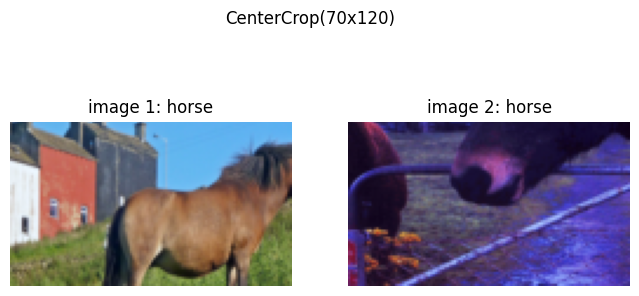

In [33]:
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plot_image(cropped_images[0])
plt.title(f'image 1: {class_names[labels[0].item()]}')
plt.subplot(1, 2, 2)
plot_image(cropped_images[1])
plt.title(f'image 2: {class_names[labels[1].item()]}')
plt.suptitle('CenterCrop(70x120)')
plt.show()

In [34]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7)
fmaps = conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 64, 114])

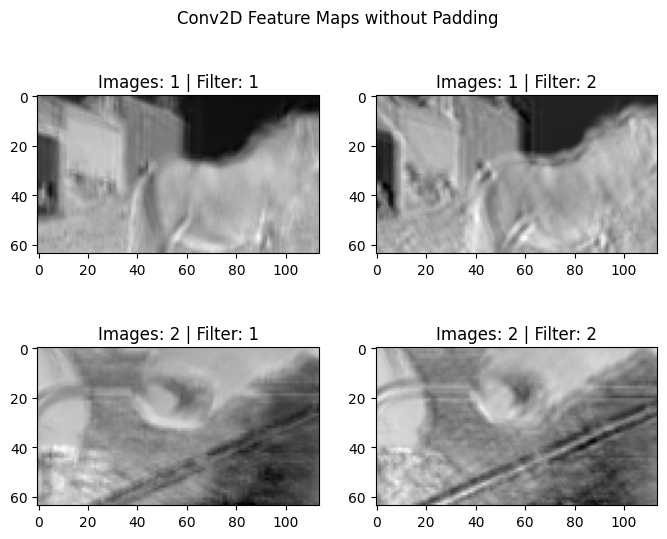

In [35]:
plt.figure(figsize=(8, 6))
for img_idx in (0, 1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx +1)
    plt.imshow(fmaps[img_idx, fmap_idx].detach(), cmap='gray')
    plt.title(f'Images: {img_idx + 1} | Filter: {fmap_idx + 1}')
plt.suptitle('Conv2D Feature Maps without Padding')
plt.show()

In [36]:
conv_layer_same = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding='same')
fmaps_same = conv_layer_same(cropped_images)
fmaps_same.shape

torch.Size([2, 32, 70, 120])

In [37]:
conv_layer_stride = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=7, padding=3, stride=2)
fmaps_stride = conv_layer_stride(cropped_images)
print(fmaps_stride.shape)
print(conv_layer_stride.weight.shape)
print(conv_layer_stride.bias.shape)

torch.Size([2, 32, 35, 60])
torch.Size([32, 3, 7, 7])
torch.Size([32])


In [38]:
import torch.nn.functional as F

torch.manual_seed(42)
filters = torch.randn([2, 3, 7,7])
biases = torch.zeros([2])
fmaps_manual = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')
fmaps_manual.shape

torch.Size([2, 2, 70, 120])

In [39]:
filtres = torch.zeros([2, 3, 7,7])
filters[0, :, :, 3] = 1
filtres[1, :, 3, :] = 1

fmaps_edge = F.conv2d(cropped_images, filters, biases, stride=1, padding='same')
fmaps_edge.shape

torch.Size([2, 2, 70, 120])

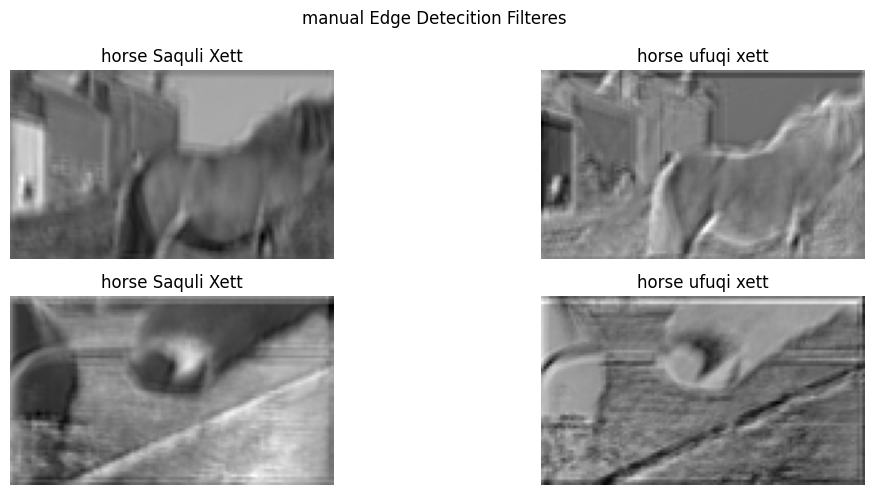

In [40]:
plt.figure(figsize=(12,5))

for img_idx in (0,1):
  for fmap_idx in (0,1):
    plt.subplot(2, 2, img_idx * 2 + fmap_idx + 1)
    plt.imshow(fmaps_edge[img_idx, fmap_idx].detach(), cmap='gray')
    title = 'Saquli Xett' if fmap_idx == 0 else 'ufuqi xett'
    plt.title(f'{class_names[labels[img_idx].item()]} {title}')
    plt.axis('off')
plt.suptitle("manual Edge Detecition Filteres ")
plt.tight_layout()
plt.show()

In [41]:
import torch.nn.functional as F

class DepthMaxPool2(torch.nn.Module):
  def __init__(self, kernel_size, stride=None, padding=0):
    super().__init__()
    self.kernel_size = kernel_size
    self.stride = stride if stride is not None else kernel_size
    self.padding = padding

  def forward(self, inputs):
    batch, channels, height, width = inputs.shape
    Z = inputs.view(batch, channels, height * width)
    Z = Z.permute(0, 2, 1)
    Z = F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride,
                         padding=self.padding)
    Z = Z.permute(0, 2, 1)
    return Z.view(batch, -1, height, width)

In [42]:
global_avg_pool = nn.AvgPool2d(kernel_size=(70, 120))

In [43]:
output = global_avg_pool(cropped_images)
output

tensor([[[[ 0.2712]],

         [[ 0.2481]],

         [[ 0.1189]]],


        [[[-1.0366]],

         [[-1.2642]],

         [[-0.4132]]]])

In [44]:
from functools import partial

torch.manual_seed(42)
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding='same')
model = nn.Sequential(

    DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=64, out_channels=128),
    nn.ReLU(),
    DefaultConv2d(in_channels=128, out_channels=128),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    DefaultConv2d(in_channels=128, out_channels=256),
    nn.ReLU(),
    DefaultConv2d(in_channels=256, out_channels=256),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Flatten(),
    nn.Linear(in_features=2304, out_features=128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=128, out_features=64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(in_features=64, out_features=10)

).to(device)

In [45]:
import torchmetrics

def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset()
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch)
  return metric.compute()


def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs):
  history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
  for epoch in range(n_epochs):
    total_loss = 0.0
    metric.reset()
    model.train()
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = loss_fn(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
      metric.update(y_pred, y_batch)
    history["train_losses"].append(total_loss / len(train_loader))
    history["train_metrics"].append(metric.compute().item())
    history["valid_metrics"].append( evaluate_tm(model, valid_loader, metric).item())


    print(f"Epoch {epoch + 1}/{n_epochs}, "
        f"train loss: {history['train_losses'][-1]:.4f}, "
        f"train metric: {history['train_metrics'][-1]:.4f}, "
        f"valid metric: {history['valid_metrics'][-1]:.4f}")

  return history

In [46]:
import torchvision
import torchvision.transforms.v2 as T

toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

train_and_valid_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(
    root="datasets", train=False, download=True, transform=toTensor)

torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(
    train_and_valid_data, [55_000, 5_000])

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]


In [47]:
from torch.utils.data import DataLoader

torch.manual_seed(42)
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

In [48]:
n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10).to(device)
history = train(model, optimizer, xentropy, accuracy, train_loader, valid_loader, n_epochs)

Epoch 1/20, train loss: 0.8964, train metric: 0.6617, valid metric: 0.8026
Epoch 2/20, train loss: 0.5116, train metric: 0.8163, valid metric: 0.8562
Epoch 3/20, train loss: 0.4217, train metric: 0.8554, valid metric: 0.8712
Epoch 4/20, train loss: 0.3745, train metric: 0.8717, valid metric: 0.8838
Epoch 5/20, train loss: 0.3487, train metric: 0.8815, valid metric: 0.8858
Epoch 6/20, train loss: 0.3257, train metric: 0.8886, valid metric: 0.8980
Epoch 7/20, train loss: 0.3086, train metric: 0.8955, valid metric: 0.9034
Epoch 8/20, train loss: 0.2900, train metric: 0.9020, valid metric: 0.8986
Epoch 9/20, train loss: 0.2801, train metric: 0.9053, valid metric: 0.8996
Epoch 10/20, train loss: 0.2669, train metric: 0.9089, valid metric: 0.9066
Epoch 11/20, train loss: 0.2658, train metric: 0.9102, valid metric: 0.9094
Epoch 12/20, train loss: 0.2487, train metric: 0.9162, valid metric: 0.9014
Epoch 13/20, train loss: 0.2448, train metric: 0.9177, valid metric: 0.9088
Epoch 14/20, train lo